In [4]:
import os
import json
import glob
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
def load_data(data_dir: str) -> list[dict]:

    json_pattern = os.path.join(data_dir, "*.json")
    json_files = glob.glob(json_pattern)
    data_list = []

    for file_path in json_files:
        with open(file_path, 'r', encoding='utf-8') as f:
            try:
                item = json.load(f)
                data_list.append(item)
            except Exception as e:
                print(f"Đọc file không thành công. {file_path}: {e}")

    print(f"=> Đã đọc thành công {len(data_list)} văn bản.\n")
    return data_list

DATA_DIR = 'selected-contexts'
dataset = load_data(DATA_DIR)


=> Đã đọc thành công 8532 văn bản.



In [6]:
passages = [doc.get('passage', '') for doc in dataset]
char_lengths = [len(p) for p in passages]
num_docs = len(dataset)
min_len = min(char_lengths) if char_lengths else 0
max_len = max(char_lengths) if char_lengths else 0
avg_len = sum(char_lengths) / num_docs if num_docs > 0 else 0
median_len = float(np.median(char_lengths)) if char_lengths else 0
print("=" * 50)
print("THỐNG KÊ ĐỘ DÀI KÝ TỰ")
print("=" * 50)
print(f"- Tổng số lượng văn bản      : {num_docs}")
print(f"- Min                        : {min_len:,} ký tự")
print(f"- Max                        : {max_len:,} ký tự")
print(f"- Mean                       : {avg_len:,.2f} ký tự")
print(f"- Median                     : {median_len:,.2f} ký tự")
print(f"- Phân vị 75%                : {np.percentile(char_lengths, 75):,.2f} ký tự")
print(f"- Phân vị 90%                : {np.percentile(char_lengths, 90):,.2f} ký tự")
print("=" * 50 + "\n")

THỐNG KÊ ĐỘ DÀI KÝ TỰ
- Tổng số lượng văn bản      : 8532
- Min                        : 0 ký tự
- Max                        : 5,983,358 ký tự
- Mean                       : 41,454.67 ký tự
- Median                     : 23,110.00 ký tự
- Phân vị 75%                : 45,786.00 ký tự
- Phân vị 90%                : 90,138.90 ký tự



### TẦN SUẤT XUẤT HIỆN CẤU TRÚC PHÁP LÝ

In [7]:
keywords = ['Điều', 'Khoản', 'Điểm']
kw_total_counts = {kw: 0 for kw in keywords}
kw_doc_counts = {kw: 0 for kw in keywords}
for p in passages:
    for kw in keywords:
        pattern = rf'\b{kw}\b'
        matches = re.findall(pattern, p, flags=re.IGNORECASE)
        count = len(matches)

        kw_total_counts[kw] += count
        if count > 0:
            kw_doc_counts[kw] += 1
print("=" * 50)
print("TẦN SUẤT XUẤT HIỆN CẤU TRÚC PHÁP LÝ")
print("=" * 50)
for kw in keywords:
    total = kw_total_counts[kw]
    docs = kw_doc_counts[kw]
    pct = (docs / num_docs * 100) if num_docs > 0 else 0
    print(f" Từ '{kw}':")
    print(f"   - Tổng số lần xuất hiện : {total:,} lần")
    print(f"   - Số văn bản có chứa    : {docs}/{num_docs} ({pct:.2f}%)")
    print(f"   - Trung bình/văn bản    : {total/num_docs:.2f} lần")
print("=" * 50 + "\n")

TẦN SUẤT XUẤT HIỆN CẤU TRÚC PHÁP LÝ
 Từ 'Điều':
   - Tổng số lần xuất hiện : 584,168 lần
   - Số văn bản có chứa    : 8400/8532 (98.45%)
   - Trung bình/văn bản    : 68.47 lần
 Từ 'Khoản':
   - Tổng số lần xuất hiện : 212,842 lần
   - Số văn bản có chứa    : 6999/8532 (82.03%)
   - Trung bình/văn bản    : 24.95 lần
 Từ 'Điểm':
   - Tổng số lần xuất hiện : 145,558 lần
   - Số văn bản có chứa    : 6720/8532 (78.76%)
   - Trung bình/văn bản    : 17.06 lần



In [8]:
token_lengths = [len(p.split()) for p in passages]
avg_tokens = sum(token_lengths) / num_docs if num_docs > 0 else 0
print(f"- Độ dài ký tự trung bình : {sum(char_lengths)/num_docs:,.2f}")
print(f"- Số từ/token trung bình  : {avg_tokens:,.2f}")

- Độ dài ký tự trung bình : 41,454.67
- Số từ/token trung bình  : 8,535.54


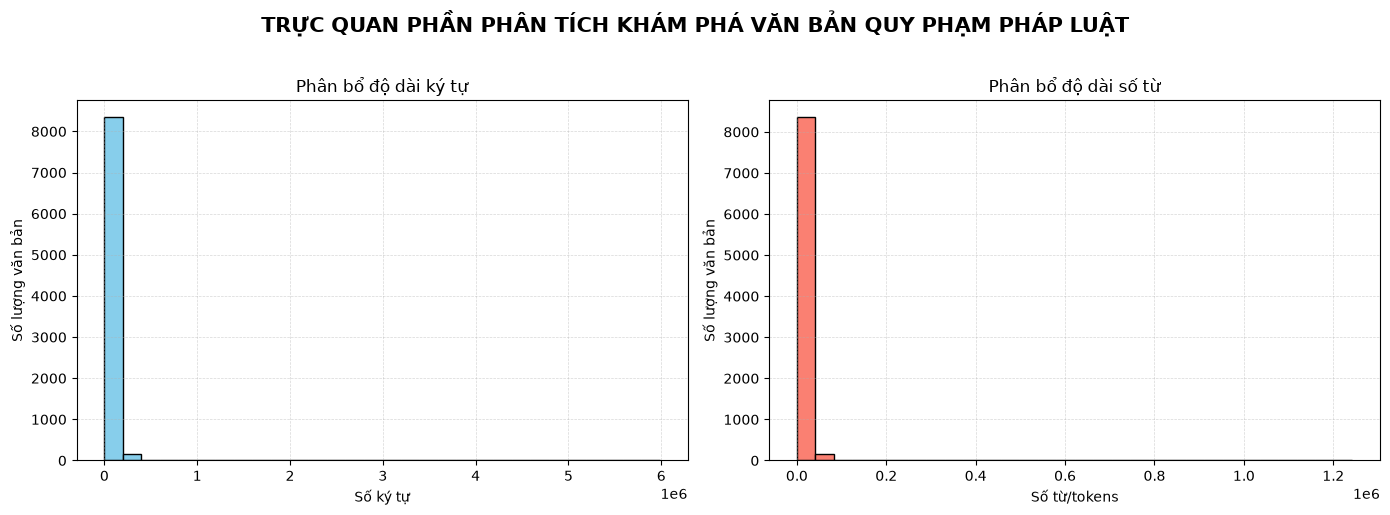

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(char_lengths, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Phân bổ độ dài ký tự')
axes[0].set_xlabel('Số ký tự')
axes[0].set_ylabel('Số lượng văn bản')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[1].hist(token_lengths, bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Phân bổ độ dài số từ')
axes[1].set_xlabel('Số từ/tokens')
axes[1].set_ylabel('Số lượng văn bản')
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.suptitle('TRỰC QUAN PHẦN PHÂN TÍCH KHÁM PHÁ VĂN BẢN QUY PHẠM PHÁP LUẬT', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Chunking

In [10]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

#### Chú thích sơ qua về bước parent-chunking
##### *Về hàm `split_parent_articles():`*

##### Mục đích
Hàm này dùng để chia một văn bản pháp luật thành nhiều "Điều". Mỗi "Điều" sau khi tách sẽ được lưu dưới dạng một dict để thuận tiện cho các bước xử lý tiếp theo

##### Input
- **`passage`**: Toàn bộ nội dung của một văn bản pháp luật (kiểu `str`).
- **`pattern`**: Sử dụng biểu thức Regex để xác định vị trí bắt đầu của mỗi Điều, ví dụ: `Điều 1`, `Điều 2`, ...

##### Quy trình xử lý

1. **Tách văn bản thành các đoạn**
   - `re.split(pattern, passage)` để chia văn bản thành nhiều phần, mỗi phần tương ứng với một Điều.

2. **Làm sạch từng đoạn**
   - Loại bỏ khoảng trắng đầu và cuối bằng `strip()`.
   - Skip những đoạn rỗng.

3. **Trích xuất tiêu đề Điều**
   - `re.search()`: để lấy phần tiêu đề của Điều (ví dụ: `Điều 5.` hoặc `Điều 12:`).
   - Nếu không tìm thấy tiêu đề, gán mặc định là `"Phần mở đầu / Khác"`.

4. **Lưu kết quả**
   - Mỗi Điều được lưu thành một dictionary gồm:
     - `article_index`: Thứ tự của Điều trong văn bản.
     - `article_title`: Tiêu đề Điều.
     - `text`: Toàn bộ nội dung của Điều.

5. **Trả về kết quả**
   - Hàm trả về một danh sách (`list`) chứa tất cả các Điều đã được chunk.

In [11]:
def split_parent_articles(passage: str, pattern: str):
    raw_chunks = re.split(pattern, passage)
    articles = []


    for idx, raw in enumerate(raw_chunks):
        cleaned = raw.strip()
        if not cleaned:
            continue

        match_title = re.search(r'^(Điều\s+\d+[^\n\.\:]*[\.\:]?)', cleaned, re.IGNORECASE)
        article_title = match_title.group(1).strip() if match_title else "Phần mở đầu / Khác"


        articles.append({
            "article_index": idx + 1,
            "article_title": article_title,
            "text": cleaned
        })
    return articles

In [12]:
def process_hierarchical_chunking(
    dataset,
    chunk_size=700,
    chunk_overlap=90,
    separators=["\nKhoản ", "\nĐiểm ", "\n\n", "\n", ". ", "; ", ", ", " "],
    parent_pattern=r"(?=(?:^|\n)\s*Điều\s+\d+[\.\:\s])"
):
    child_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=separators,
        length_function=len
    )

    all_chunks = []
    for doc in dataset:
        doc_id = doc.get("id", "unknown_id")
        doc_name = doc.get("name", doc.get("title", f"Văn bản {doc_id}"))
        doc_link = doc.get("link", "")
        passage = doc.get("passage", "")

        if not passage or not passage.strip():
            continue

        parent_articles = split_parent_articles(passage, parent_pattern)

        for p_idx, parent in enumerate(parent_articles):
            parent_text = parent["text"]
            article_title = parent["article_title"]

            sub_texts = [parent_text] if len(parent_text) <= chunk_size else child_splitter.split_text(parent_text)

            for c_idx, sub_text in enumerate(sub_texts):
                chunk_id = f"{doc_id}_art{p_idx+1}_c{c_idx+1}"
                all_chunks.append({
                    "chunk_id": chunk_id,
                    "doc_id": doc_id,
                    "doc_name": doc_name,
                    "doc_link": doc_link,
                    "parent_article": article_title,
                    "parent_index": p_idx + 1,
                    "child_index": c_idx + 1,
                    "chunk_text": sub_text,
                    "char_length": len(sub_text),
                    "word_length": len(sub_text.split())
                })
    return all_chunks

In [13]:
CHUNK_SIZE = 700
CHUNK_OVERLAP = 90
SEPARATORS = ["\nKhoản ", "\nĐiểm ", "\n\n", "\n", ". ", "; ", ", ", " "]
PARENT_PATTERN = r"(?=(?:^|\n)\s*Điều\s+\d+[\.\:\s])"
final_chunks = process_hierarchical_chunking(
    dataset=dataset,
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=SEPARATORS,
    parent_pattern=PARENT_PATTERN
)
print(f" Đã xử lí xong. Tổng số chunks là: {len(final_chunks)}")

 Đã xử lí xong. Tổng số chunks là: 653400


#### Test: Xem thử toàn bộ chunks của 1 văn bản bất kì

In [14]:
target_doc_id = dataset[2]['id']

doc_chunks = [c for c in final_chunks if c['doc_id'] == target_doc_id]

print(f" TẤT CẢ CHUNKS CỦA VĂN BẢN ID [{target_doc_id}] (Tổng số: {len(doc_chunks)} chunks):\n")
for c in doc_chunks:
    print(f"-------- [{c['chunk_id']}] | {c['parent_article']} | Child #{c['child_index']} ({c['word_length']} từ) --------")


    print(c['chunk_text'][:50].replace('\n', ' ') + "...\n")

 TẤT CẢ CHUNKS CỦA VĂN BẢN ID [100109] (Tổng số: 108 chunks):

-------- [100109_art1_c1] | Phần mở đầu / Khác | Child #1 (125 từ) --------
    HÒA ...  CỘNGHỦ

-------- [100109_art2_c1] | Điều 1. | Child #1 (139 từ) --------
Điều 1. Ban hành Chiến lược phát triển khoa học, c...

-------- [100109_art2_c2] | Điều 1. | Child #2 (137 từ) --------
là nền tảng để thực hiện chuyển đổi số quốc gia; g...

-------- [100109_art2_c3] | Điều 1. | Child #3 (144 từ) --------
  phát triển năn... hiệu quả giữa

-------- [100109_art2_c4] | Điều 1. | Child #4 (140 từ) --------
Nam có nhu cầu, tiềm năng và lợi thế.  II. MỤC TIÊ...

-------- [100109_art2_c5] | Điều 1. | Child #5 (139 từ) --------
nghệ và đổi mới sáng tạo đạt mức tiên tiến ở nhiều...

-------- [100109_art2_c6] | Điều 1. | Child #6 (141 từ) --------
trị, tổ chức trong doanh nghiệp. Đóng góp của năng...

-------- [100109_art2_c7] | Điều 1. | Child #7 (140 từ) --------
chế biến, chế tạo đạt tối thiểu 45%.  c) Khoa học,...

-------- [100109_art

In [15]:
# DATA_STATEMENT_CONFIG = {
#     "chunking_strategy": "Hierarchical Chunking (Parent: Article Regex, Child: RecursiveCharacter)",
#     "parent_splitter_regex": r"(?=(?:^|\n)\s*Điều\s+\d+[\.\:\s])",
#     "child_chunk_size": 700,
#     "child_chunk_overlap": 90,
#     "separators": ["\nKhoản ", "\nĐiểm ", "\n\n", "\n", ". ", "; ", ", ", " "],
#     "target_model_scale": "< 4B Parameters",
#     "meteor_optimization": "Vietnamese Clause & Word Boundary Splitting (No Word Fragmentation)",
#     "offline_execution": True
# }
# def export_data_statement(config: dict, output_path: str = "data_statement_config.json"):
#
#     with open(output_path, "w", encoding="utf-8") as f:
#         json.dump(config, f, ensure_ascii=False, indent=4)
#     print(f"Đã xuất thông số Data Statement ra file: {output_path}")